# 🎭 5. Centros Culturales (OTRA OFERTA INSTITUCIONAL)

👉 Complementa el deporte (bienestar social) y nos permite ver el mapa de acceso cultural de los jóvenes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Carga de Datos Preprocesados

In [2]:
PROCESSED_DIR = '../../01_datos/processed'
file_path = os.path.join(PROCESSED_DIR, 'p_centros_culturales_bogota_limpio.xlsx')

if os.path.exists(file_path):
    df_cultura = pd.read_excel(file_path)
    print(f'Total de registros cargados: {len(df_cultura):,}')
    display(df_cultura.head(3))
else:
    print('El archivo de Cultura procesado no fue encontrado.')

Total de registros cargados: 99


,Nombre,Dirección,Localidad,UPZ,Entidad Administradora,Carácter,Uso Principal
0,Centro Musical La Gaitana,TV 126 133 32,Suba,Tibabuyes,FUNDACIÓN NACIONAL BATUTA,Público,Centro Cultural y Artístico
1,Academia Colombiana De La Lengua,AK 3 17 23,Santa Fe,Las Nieves,ACADEMIA COLOMBIANA DE LA LENGUA - JAIME POZAD...,Privado,Centro Cultural y Artístico
2,Parque Zonal La Amistad,KR 78J 41 10 SUR,Kennedy,Kennedy Central,INSTITUTO DISTRITAL DE RECREACIÓN Y DEPORTE -IDRD,Público,Centro Cultural y Artístico


## 📍 Cobertura y 📊 Densidad
**¿Dónde están concentrados? ¿Cuántos centros por localidad?**

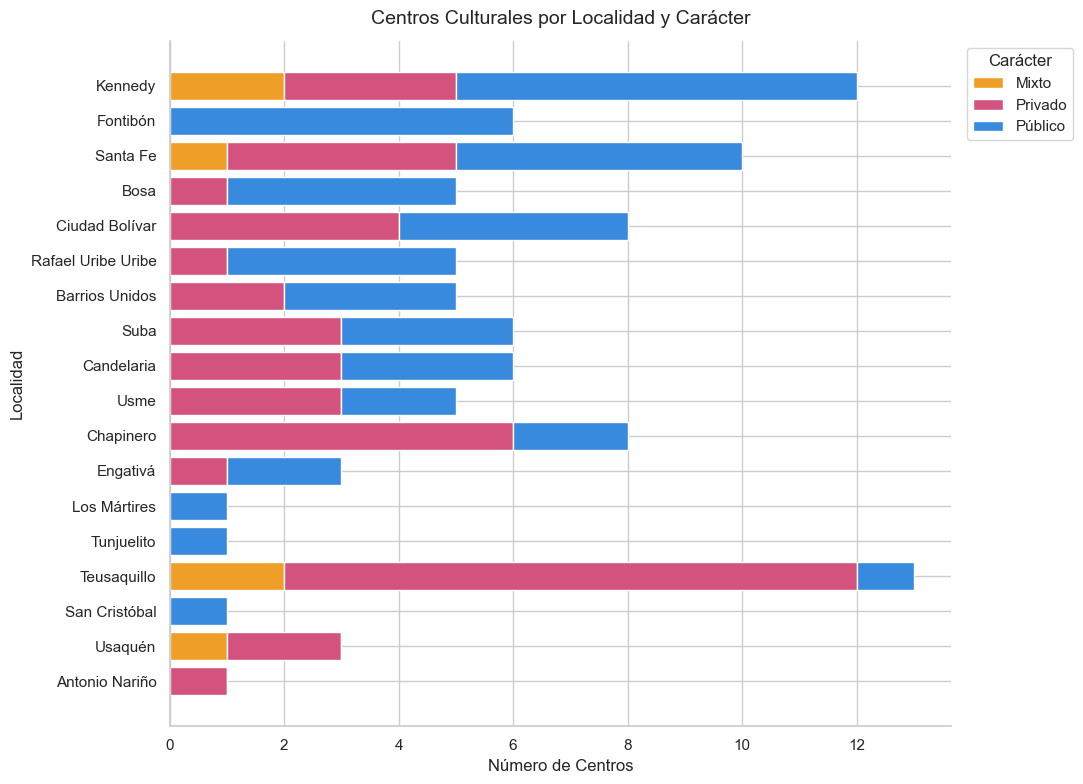

In [9]:
col_loc = next((c for c in df_cultura.columns if c.lower() == 'localidad'), None)
col_car = next((c for c in df_cultura.columns if 'car' in c.lower()), None)  # Carácter (Público/Privado)

if col_loc and col_car:
    pivot = (
        df_cultura.groupby([col_loc, col_car])
        .size()
        .unstack(fill_value=0)
        .sort_values(by=df_cultura[col_car].value_counts().index[0], ascending=True)
    )

    colors = {'Público': '#378ADD', 'Privado': '#D4537E', 'Mixto': '#EF9F27'}
    
    fig, ax = plt.subplots(figsize=(11, 8))
    
    left = np.zeros(len(pivot))
    for col in pivot.columns:
        ax.barh(pivot.index, pivot[col], left=left,
                label=col, color=colors.get(col, '#888'))
        left += pivot[col].values

    ax.set_title('Centros Culturales por Localidad y Carácter', fontsize=14, pad=12)
    ax.set_xlabel('Número de Centros')
    ax.set_ylabel('Localidad')
    ax.legend(title='Carácter', bbox_to_anchor=(1.01, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()

## 🧭 Distribución
**¿Hay zonas sin acceso? (Lagunas culturales)**

=== Distribución por carácter de centros culturales ===

Público      49 centros    49.5%  ████████████████████████
Privado      44 centros    44.4%  ██████████████████████
Mixto         6 centros     6.1%  ███

TOTAL        99 centros   100.0%


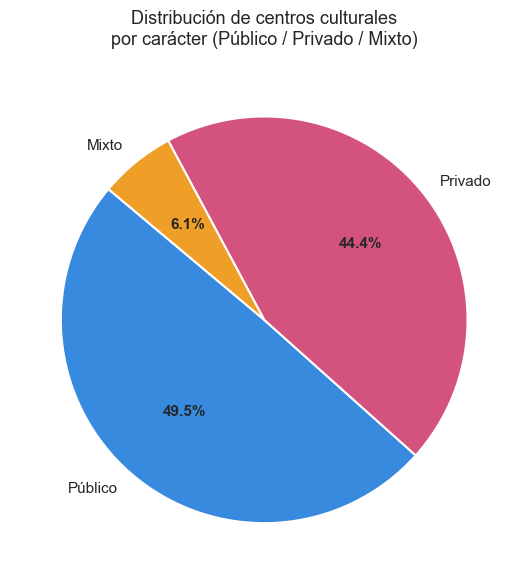

In [10]:
col_car = next((c for c in df_cultura.columns if 'car' in c.lower()), None)

if col_car:
    conteo = df_cultura[col_car].value_counts()
    total = conteo.sum()
    
    print('=== Distribución por carácter de centros culturales ===\n')
    for nombre, cantidad in conteo.items():
        pct = cantidad / total * 100
        barra = '█' * int(pct / 2)
        print(f'{nombre:<10} {cantidad:>4} centros   {pct:>5.1f}%  {barra}')
    
    print(f'\n{"TOTAL":<10} {total:>4} centros   100.0%')
    
    # Gráfica de torta
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = ['#378ADD', '#D4537E', '#EF9F27']
    wedges, texts, autotexts = ax.pie(
        conteo.values,
        labels=conteo.index,
        autopct='%1.1f%%',
        colors=colors[:len(conteo)],
        startangle=140,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
    )
    for t in autotexts:
        t.set_fontsize(11)
        t.set_fontweight('bold')
    ax.set_title('Distribución de centros culturales\npor carácter (Público / Privado / Mixto)', fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()